# Exploración de datos

## 1. Contexto y objetivo
El objetivo de este proyecto es analizar la producción de petróleo de pozos no convencionales de Argentina y explorar si las características de los pozos y su historial de producción permiten predecir su comportamiento productivo futuro.

La pregunta principal que buscamos responder es:

> **Dadas las características de un pozo y su historial de producción, ¿cuánto petróleo esperamos que produzca el próximo mes?**

A partir de esta pregunta se plantean tres enfoques de Machine Learning:

- **Regresión:** predecir la cantidad de petróleo que producirá un pozo durante el próximo mes.
- **Clasificación:** categorizar la producción futura del pozo en diferentes niveles de producción.
- **Clustering:** identificar grupos de pozos con características y comportamientos productivos similares.

En esta primera etapa del proyecto realizaremos una exploración de los datos disponibles, buscando comprender su estructura, calidad, variables relevantes y relaciones entre las diferentes fuentes de información.

### Importación de librerías

Para realizar el análisis exploratorio utilizaremos principalmente **Pandas**, **NumPy** y **Matplotlib**.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Indicamos que se visualicen todas las columnas del dataframe
pd.set_option("display.max_columns", None)

### Carga de los datasets

Para el análisis utilizaremos tres fuentes principales de información:

1. **Producción no convencional:** contiene registros mensuales de producción de petróleo, gas, agua y otras variables asociadas a los pozos no convencionales.
2. **Características de los pozos:** contiene información descriptiva de los pozos, como profundidad, formación, cuenca, tipo de recurso y tipo de extracción.
3. **Fracturación:** contiene información relacionada con las operaciones de fracturación de los pozos, incluyendo cantidad de fracturas, longitud de la rama horizontal, arena y agua utilizadas, entre otras variables.

Los archivos originales se mantienen sin modificar dentro de `data/raw/`.

In [3]:
produccion = pd.read_csv(
    "../data/raw/produccin-de-pozos-de-gas-y-petrleo-no-convencional.csv"
)

pozos = pd.read_csv(
    "../data/raw/capitulo-iv-pozos.csv"
)

fracturacion = pd.read_csv(
    "../data/raw/datos-de-fractura-de-pozos-de-hidrocarburos-adjunto-iv-actualizacin-diaria.csv"
)

## 2. Inspección inicial de los datasets

En esta primera etapa queremos conocer la estructura general de los datasets y verificar que los archivos hayan sido importados correctamente.

Antes de realizar transformaciones o eliminar datos, analizaremos:

- la cantidad de filas y columnas de cada dataset;
- los nombres de las variables disponibles;
- los tipos de datos;
- una muestra de los registros;
- la presencia de valores nulos;
- la existencia de registros duplicados.

Esta inspección inicial nos permitirá comprender qué información contiene cada fuente y detectar posibles problemas de calidad que deberán ser considerados durante las etapas posteriores del análisis.

> **Importante:** en esta etapa no eliminaremos datos automáticamente. Primero analizaremos qué representan y si los valores faltantes, ceros o duplicados tienen un significado dentro del problema.

### 2.1 Dimensiones de los datasets

Comenzamos revisando las dimensiones de cada dataset.

El atributo `shape` de Pandas devuelve una tupla con la siguiente estructura:

```text
(filas, columnas)

In [4]:
resumen_dimensiones = pd.DataFrame({
    "Dataset": [
        "Producción no convencional",
        "Pozos",
        "Fracturación"
    ],
    "Filas": [
        produccion.shape[0],
        pozos.shape[0],
        fracturacion.shape[0]
    ],
    "Columnas": [
        produccion.shape[1],
        pozos.shape[1],
        fracturacion.shape[1]
    ]
})

display(resumen_dimensiones)

,Dataset,Filas,Columnas
0,Producción no convencional,421046,40
1,Pozos,85611,26
2,Fracturación,4890,30


### 2.2. Nombres de las variables

Una vez conocidas las dimensiones de los datasets, analizamos las variables disponibles en cada fuente.

Conocer los nombres de las columnas nos permite identificar qué tipo de información contiene cada dataset y comenzar a determinar qué variables podrían ser relevantes para nuestro problema de predicción.

En particular, nos interesa identificar:

- variables que describan las características de los pozos;
- variables relacionadas con la producción;
- variables temporales, como año y mes;
- variables relacionadas con la fracturación;
- identificadores que permitan relacionar los diferentes datasets.

En esta etapa solamente identificaremos las variables disponibles.

In [5]:
columnas_datasets = pd.DataFrame({
    "Producción": pd.Series(produccion.columns),
    "Pozos": pd.Series(pozos.columns),
    "Fracturación": pd.Series(fracturacion.columns)
})

display(columnas_datasets)

,Producción,Pozos,Fracturación
0,idempresa,sigla,id_base_fractura_adjiv
1,anio,idpozo,idpozo
2,mes,area,sigla
3,idpozo,cod_area,cuenca
4,prod_pet,empresa,areapermisoconcesion
5,prod_gas,yacimiento,yacimiento
6,prod_agua,cod_yacimiento,formacion_productiva
7,iny_agua,formacion,tipo_reservorio
8,iny_gas,cuenca,subtipo_reservorio
9,iny_co2,provincia,longitud_rama_horizontal_m


### 2.3. Primer vistazo a los registros

Los nombres de las columnas nos permiten conocer qué variables están disponibles, pero todavía no muestran cómo están representados los datos.

Para obtener una primera visión del contenido de cada dataset utilizaremos `head()`, que permite visualizar los primeros registros.

Esta inspección nos ayuda a:

- comprobar que los datos fueron cargados correctamente;
- observar el formato de los valores;
- identificar posibles inconsistencias evidentes;
- relacionar los nombres de las variables con los valores que contienen.

La visualización de los primeros registros no implica que estos sean representativos de todo el dataset. Se utiliza únicamente como una primera inspección.

In [6]:
print("Primeros registros del dataset de producción:")
display(produccion.head())

Primeros registros del dataset de producción:


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,iny_otro,tef,vida_util,tipoextraccion,tipoestado,tipopozo,observaciones,fechaingreso,rectificado,habilitado,idusuario,empresa,sigla,formprod,profundidad,formacion,idareapermisoconcesion,areapermisoconcesion,idareayacimiento,areayacimiento,cuenca,provincia,coordenadax,coordenaday,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
0,YSUR,2015,1,132909,16.74,241.220,13.42,0.0,0.0,0.0,0.0,31.00,NaN,Plunger Lift,Extracción Efectiva,Gasífero,NaN,2015-02-26 13:35:35.533458,f,t,5,YSUR ENERGÍA ARGENTINA S.R.L.,AEA.NQ.RCo-1039,PREC,2678.0,precuyo,SDD,AL SUR DE LA DORSAL,RQC,RANQUIL CO,NEUQUINA,Neuquén,-69.202207,-39.081820,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2015-01-31
1,YSUR,2018,1,132488,0.00,171.937,0.00,0.0,0.0,0.0,0.0,30.73,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2018-02-10 08:37:14.717426,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,AEA.RN.EFO-99(d),LAJA,3828.0,lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.864960,-39.016722,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
2,YSUR,2017,1,134325,22.34,365.610,1.20,0.0,0.0,0.0,0.0,31.00,NaN,Plunger Lift,Extracción Efectiva,Gasífero,NaN,2017-02-16 13:45:37.233373,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,APA.RN.EFO-117(d),LAJA,3793.0,lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.849735,-39.020644,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2017-01-31
3,YSUR,2018,1,132487,0.00,514.696,17.00,0.0,0.0,0.0,0.0,29.90,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2018-02-10 08:37:14.717426,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,APA.RN.EFO-139(d),FIMP,2707.0,formación improductiva,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.837875,-39.019313,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
4,YSUR,2016,1,153522,234.87,1651.240,94.12,0.0,0.0,0.0,0.0,30.79,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2016-02-17 10:50:46.929347,f,t,5,YSUR ENERGÍA ARGENTINA S.R.L.,APA.RN.EFO-231(d),LAJA,3844.0,lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.810843,-39.024083,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2016-01-31


In [7]:
print("Primeros registros del dataset de pozos:")
display(pozos.head())

Primeros registros del dataset de pozos:


,sigla,idpozo,area,cod_area,empresa,yacimiento,cod_yacimiento,formacion,cuenca,provincia,cota,profundidad,clasificacion,subclasificacion,tipo_recurso,sub_tipo_recurso,gasplus,tipopozo,tipoextraccion,tipoestado,adjiv_fecha_inicio_perf,adjiv_fecha_fin_perf,adjiv_fecha_inicio_term,adjiv_fecha_fin_term,geojson,geom
0,CH.CH.EaLE.x-1,212,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,255.00,1702.0,EXPLORACION,EXPLORACION,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1996-10-30,1996-11-13,1996-11-17,1996-12-07,"{""type"":""Point"",""coordinates"":[-68.28785299999...",0101000020E61000008D43FD2E6C1251C00E4B033FAACB...
1,CH.CH.EaLE.x-2,213,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,251.00,1350.0,EXPLORACION,EXPLORACION,CONVENCIONAL,No informado,no,Inyección de Agua,Sin Sistema de Extracción,En Inyección Efectiva,1996-10-14,1996-11-13,1996-12-09,1996-12-17,"{""type"":""Point"",""coordinates"":[-68.29201899999...",0101000020E6100000E1B37570B01251C00BB5A679C7CB...
2,CH.CH.EaLE-3,214,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,256.15,1350.0,EXPLOTACION,DESARROLLO,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1997-01-30,1997-02-07,1997-03-02,1997-03-10,"{""type"":""Point"",""coordinates"":[-68.28387800000...",0101000020E61000007383A10E2B1251C082548A1D8DCB...
3,CH.CH.EaLE-4,215,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,256.70,1351.0,EXPLOTACION,DESARROLLO,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1997-01-13,1997-01-20,1997-01-23,1997-02-07,"{""type"":""Point"",""coordinates"":[-68.28948300000...",0101000020E6100000DF6FB4E3861251C0A148F7730ACC...
4,CH.CH.EaLE-5,216,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,256.00,1350.0,EXPLOTACION,DESARROLLO,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1997-02-16,1997-02-24,1997-03-10,1997-03-18,"{""type"":""Point"",""coordinates"":[-68.29447500000...",0101000020E6100000569FABADD81251C0B98D06F016CC...


In [8]:
print("Primeros registros del dataset de fracturación:")
display(fracturacion.head())

Primeros registros del dataset de fracturación:


,id_base_fractura_adjiv,idpozo,sigla,cuenca,areapermisoconcesion,yacimiento,formacion_productiva,tipo_reservorio,subtipo_reservorio,longitud_rama_horizontal_m,cantidad_fracturas,tipo_terminacion,arena_bombeada_nacional_tn,arena_bombeada_importada_tn,agua_inyectada_m3,co2_inyectado_m3,presion_maxima_psi,potencia_equipos_fractura_hp,fecha_inicio_fractura,fecha_fin_fractura,fecha_data,anio_if,mes_if,anio_ff,mes_ff,anio_carga,mes_carga,empresa_informante,mes,anio
0,30,159910,APS.Nq.ADC.xp-1033,NEUQUINA,AGUA DEL CAJON,AGUA DEL CAJON,los molles,NO CONVENCIONAL,SHALE,0.0,3,Punzado,0.000,0.000,2718.20,0.0,10190.0,10897.0,2019-04-20,2019-04-30,2019-06-14 17:13:03.68279,2019,4,2019,4,2019,6,CAPEX S.A.,4,2019
1,31,159910,APS.Nq.ADC.xp-1033,NEUQUINA,AGUA DEL CAJON,AGUA DEL CAJON,los molles,NO CONVENCIONAL,SHALE,0.0,1,Punzado,0.000,0.000,600.00,0.0,9250.0,10251.0,2018-11-02,2018-11-03,2019-06-14 17:14:19.179874,2018,11,2018,11,2019,6,CAPEX S.A.,11,2018
2,37,159219,YPF.Nq.AdlA-1001(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,1437.3,18,Tapón disparo,3761.370,536.850,25768.30,0.0,15000.0,32000.0,2017-11-19,2017-12-14,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017
3,38,159220,YPF.Nq.AdlA-1002(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,1518.3,19,Tapón disparo,3903.705,558.225,27398.37,0.0,11348.0,32000.0,2017-11-21,2017-12-15,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017
4,39,159221,YPF.Nq.AdlA-1003(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,1482.3,19,Tapón disparo,3949.020,569.925,27157.60,0.0,11076.0,32000.0,2017-11-18,2017-12-15,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017


### 2.4. Tipos de datos

A continuación analizamos el tipo de dato asignado por Pandas a cada variable.

Los tipos de datos son importantes porque determinan qué operaciones podemos realizar sobre cada columna.

Por ejemplo:

- las variables numéricas pueden utilizarse para cálculos estadísticos;
- las variables de texto permiten agrupar o analizar categorías;
- las variables de fecha requieren un tratamiento específico para realizar análisis temporales.

Esta revisión también nos permite detectar columnas que eventualmente deberán ser transformadas antes del análisis o del entrenamiento de los modelos.

In [9]:
print("Tipos de datos - Producción:")
display(produccion.dtypes)

Tipos de datos - Producción:


idempresa                     str
anio                        int64
mes                         int64
idpozo                      int64
prod_pet                  float64
prod_gas                  float64
prod_agua                 float64
iny_agua                  float64
iny_gas                   float64
iny_co2                   float64
iny_otro                  float64
tef                       float64
vida_util                 float64
tipoextraccion                str
tipoestado                    str
tipopozo                      str
observaciones                 str
fechaingreso                  str
rectificado                   str
habilitado                    str
idusuario                   int64
empresa                       str
sigla                         str
formprod                      str
profundidad               float64
formacion                     str
idareapermisoconcesion        str
areapermisoconcesion          str
idareayacimiento              str
areayacimiento

In [10]:
print("Tipos de datos - Pozos:")
display(pozos.dtypes)

Tipos de datos - Pozos:


sigla                          str
idpozo                       int64
area                           str
cod_area                       str
empresa                        str
yacimiento                     str
cod_yacimiento                 str
formacion                      str
cuenca                         str
provincia                      str
cota                       float64
profundidad                float64
clasificacion                  str
subclasificacion               str
tipo_recurso                   str
sub_tipo_recurso               str
gasplus                        str
tipopozo                       str
tipoextraccion                 str
tipoestado                     str
adjiv_fecha_inicio_perf        str
adjiv_fecha_fin_perf           str
adjiv_fecha_inicio_term        str
adjiv_fecha_fin_term           str
geojson                        str
geom                           str
dtype: object

In [11]:
print("Tipos de datos - Fracturación:")
display(fracturacion.dtypes)

Tipos de datos - Fracturación:


id_base_fractura_adjiv            int64
idpozo                            int64
sigla                               str
cuenca                              str
areapermisoconcesion                str
yacimiento                          str
formacion_productiva                str
tipo_reservorio                     str
subtipo_reservorio                  str
longitud_rama_horizontal_m      float64
cantidad_fracturas                int64
tipo_terminacion                    str
arena_bombeada_nacional_tn      float64
arena_bombeada_importada_tn     float64
agua_inyectada_m3               float64
co2_inyectado_m3                float64
presion_maxima_psi              float64
potencia_equipos_fractura_hp    float64
fecha_inicio_fractura               str
fecha_fin_fractura                  str
fecha_data                          str
anio_if                           int64
mes_if                            int64
anio_ff                           int64
mes_ff                            int64


### 2.5. Información general de los datasets

Utilizamos el método `info()` para obtener un resumen general de cada DataFrame.

Esta función permite observar:

- cantidad de registros;
- cantidad de columnas;
- nombre de las variables;
- cantidad de valores no nulos;
- tipo de dato de cada variable;
- uso aproximado de memoria.

Esta información será útil para detectar variables con valores faltantes y posibles diferencias entre los tipos de datos esperados y los encontrados.

In [12]:
print("Resumen general - Producción:")
produccion.info()

Resumen general - Producción:


<class 'pandas.DataFrame'>
RangeIndex: 421046 entries, 0 to 421045
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idempresa               421046 non-null  str    
 1   anio                    421046 non-null  int64  
 2   mes                     421046 non-null  int64  
 3   idpozo                  421046 non-null  int64  
 4   prod_pet                421046 non-null  float64
 5   prod_gas                421046 non-null  float64
 6   prod_agua               421046 non-null  float64
 7   iny_agua                421046 non-null  float64
 8   iny_gas                 421046 non-null  float64
 9   iny_co2                 421046 non-null  float64
 10  iny_otro                421046 non-null  float64
 11  tef                     421046 non-null  float64
 12  vida_util               8964 non-null    float64
 13  tipoextraccion          420432 non-null  str    
 14  tipoestado              420432 

In [13]:
print("Resumen general - Pozos:")
pozos.info()

Resumen general - Pozos:
<class 'pandas.DataFrame'>
RangeIndex: 85611 entries, 0 to 85610
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sigla                    85611 non-null  str    
 1   idpozo                   85611 non-null  int64  
 2   area                     85611 non-null  str    
 3   cod_area                 85611 non-null  str    
 4   empresa                  84647 non-null  str    
 5   yacimiento               85611 non-null  str    
 6   cod_yacimiento           85611 non-null  str    
 7   formacion                82796 non-null  str    
 8   cuenca                   85611 non-null  str    
 9   provincia                85611 non-null  str    
 10  cota                     85611 non-null  float64
 11  profundidad              85611 non-null  float64
 12  clasificacion            85611 non-null  str    
 13  subclasificacion         85611 non-null  str    
 14  tipo_rec

In [14]:
print("Resumen general - Fracturación:")
fracturacion.info()

Resumen general - Fracturación:
<class 'pandas.DataFrame'>
RangeIndex: 4890 entries, 0 to 4889
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_base_fractura_adjiv        4890 non-null   int64  
 1   idpozo                        4890 non-null   int64  
 2   sigla                         4890 non-null   str    
 3   cuenca                        4890 non-null   str    
 4   areapermisoconcesion          4890 non-null   str    
 5   yacimiento                    4890 non-null   str    
 6   formacion_productiva          4890 non-null   str    
 7   tipo_reservorio               4855 non-null   str    
 8   subtipo_reservorio            3916 non-null   str    
 9   longitud_rama_horizontal_m    4890 non-null   float64
 10  cantidad_fracturas            4890 non-null   int64  
 11  tipo_terminacion              4890 non-null   str    
 12  arena_bombeada_nacional_tn    4890 non-nu

### 2.6. Análisis de valores faltantes

Los valores faltantes son registros en los que una variable no contiene información.

Su presencia no implica necesariamente un error en los datos. En algunos casos puede significar que una característica no fue informada, que no corresponde al registro o que la fuente original no disponía de ese dato.

Por este motivo, en esta etapa no eliminaremos automáticamente las filas o columnas con valores faltantes. Primero identificaremos su cantidad y proporción para evaluar posteriormente cómo tratarlos.

Calcularemos:

- cantidad de valores faltantes por variable;
- porcentaje de valores faltantes respecto del total de registros.

In [15]:
def resumen_nulos(df):
    resumen = pd.DataFrame({
        "Valores nulos": df.isnull().sum(),
        "Porcentaje nulos": df.isnull().mean() * 100
    })
    
    return resumen.sort_values(
        by="Porcentaje nulos",
        ascending=False
    )

In [16]:
print("Valores faltantes - Producción")
display(resumen_nulos(produccion))

Valores faltantes - Producción


,Valores nulos,Porcentaje nulos
vida_util,412082,97.871016
observaciones,397045,94.299673
clasificacion,922,0.218978
subclasificacion,922,0.218978
tipopozo,614,0.145827
tipoextraccion,614,0.145827
tipoestado,614,0.145827
sub_tipo_recurso,452,0.107352
iny_agua,0,0.000000
prod_agua,0,0.000000


In [17]:
print("Valores faltantes - Pozos")
display(resumen_nulos(pozos))

Valores faltantes - Pozos


,Valores nulos,Porcentaje nulos
adjiv_fecha_inicio_term,36487,42.619523
adjiv_fecha_fin_term,36486,42.618355
adjiv_fecha_fin_perf,34149,39.888566
adjiv_fecha_inicio_perf,34004,39.719195
formacion,2815,3.288129
empresa,964,1.126024
idpozo,0,0.000000
sigla,0,0.000000
cod_area,0,0.000000
area,0,0.000000


In [18]:
print("Valores faltantes - Fracturación")
display(resumen_nulos(fracturacion))

Valores faltantes - Fracturación


,Valores nulos,Porcentaje nulos
subtipo_reservorio,974,19.918200
potencia_equipos_fractura_hp,51,1.042945
tipo_reservorio,35,0.715746
sigla,0,0.000000
id_base_fractura_adjiv,0,0.000000
cuenca,0,0.000000
yacimiento,0,0.000000
areapermisoconcesion,0,0.000000
formacion_productiva,0,0.000000
longitud_rama_horizontal_m,0,0.000000


#### 2.6.1. Valores faltantes en el dataset de producción

El dataset de producción presenta una cobertura completa para las principales variables productivas.

En particular, las variables `prod_pet`, `prod_gas`, `prod_agua`, `idpozo`, `anio` y `mes` no presentan valores faltantes.

La variable `vida_util` presenta un porcentaje muy elevado de valores ausentes (97,87%), mientras que `observaciones` presenta un 94,30% de valores ausentes. Debido a esta baja cobertura, estas variables deberán analizarse antes de considerar su utilización en etapas posteriores.

El resto de las variables con valores faltantes presenta porcentajes inferiores al 0,25%, por lo que su impacto sobre el conjunto de datos es reducido.

Por el momento no se eliminarán estas variables ni se imputarán sus valores. Su tratamiento se definirá posteriormente en función de su utilidad para el análisis y los modelos.

#### 2.6.2. Valores faltantes en el dataset de pozos

En el dataset de características de los pozos se observa una cobertura completa en la mayoría de las variables.

Las principales ausencias se concentran en las variables relacionadas con las fechas de perforación y terminación:

- `adjiv_fecha_inicio_term`: 42,62% de valores faltantes.
- `adjiv_fecha_fin_term`: 42,62%.
- `adjiv_fecha_fin_perf`: 39,89%.
- `adjiv_fecha_inicio_perf`: 39,72%.

También se observan valores faltantes en `formacion` (3,29%) y `empresa` (1,13%).

Los valores faltantes en las fechas deberán analizarse considerando que no necesariamente representan un error: pueden corresponder a pozos para los cuales determinada información no fue registrada o no se encuentra disponible en la fuente.

Por lo tanto, estas variables no serán eliminadas automáticamente y su tratamiento se definirá según su utilización en el análisis posterior.

#### 2.6.3. Valores faltantes en el dataset de fracturación

El dataset de fracturación presenta una cobertura elevada en la mayoría de sus variables.

La principal excepción es `subtipo_reservorio`, que presenta un 19,92% de valores faltantes. También se observan valores ausentes en `potencia_equipos_fractura_hp` (1,04%) y `tipo_reservorio` (0,72%).

Las variables directamente relacionadas con las características de la fracturación, como `longitud_rama_horizontal_m`, `cantidad_fracturas`, `arena_bombeada_nacional_tn`, `arena_bombeada_importada_tn`, `agua_inyectada_m3` y `presion_maxima_psi`, no presentan valores faltantes.

Esto resulta especialmente relevante para nuestro análisis, ya que estas variables podrían utilizarse posteriormente para caracterizar los pozos y estudiar su relación con el comportamiento productivo.

#### 2.6.4. Conclusiones sobre los valores faltantes

El análisis muestra que los tres datasets presentan, en general, una alta cobertura de información.

Las principales situaciones detectadas son:

- En **producción**, `vida_util` y `observaciones` presentan una proporción muy elevada de valores faltantes, mientras que las variables productivas principales no presentan ausencias.
- En **pozos**, los valores faltantes se concentran principalmente en las fechas de perforación y terminación.
- En **fracturación**, `subtipo_reservorio` presenta la mayor proporción de valores faltantes, mientras que las principales variables cuantitativas relacionadas con la fracturación presentan información completa.

En consecuencia, no se realizará una eliminación general de valores faltantes. El tratamiento será definido posteriormente según el uso de cada variable y las necesidades de los modelos.

Además, se tendrá especial cuidado en diferenciar los valores faltantes (`NaN`) de los valores cero, ya que un cero puede representar una medición real de producción o de otra variable.

### 2.7. Análisis de registros duplicados

Antes de realizar transformaciones, verificaremos si existen registros duplicados en las diferentes fuentes de datos.

Es importante diferenciar entre un registro completamente duplicado y la repetición de un identificador como `idpozo`.

En el dataset de producción es esperable que un mismo `idpozo` aparezca varias veces, ya que cada registro representa la producción de un pozo en un determinado período.

Por lo tanto, la repetición de `idpozo` no será considerada por sí sola como un duplicado. Primero analizaremos los registros completamente repetidos y luego la cantidad de registros y períodos disponibles para cada pozo.

In [19]:
resumen_duplicados = pd.DataFrame({
    "Dataset": [
        "Producción no convencional",
        "Pozos",
        "Fracturación"
    ],
    "Registros duplicados": [
        produccion.duplicated().sum(),
        pozos.duplicated().sum(),
        fracturacion.duplicated().sum()
    ]
})

display(resumen_duplicados)

,Dataset,Registros duplicados
0,Producción no convencional,0
1,Pozos,0
2,Fracturación,0


#### Conclusiones sobre los registros duplicados

No se encontraron registros completamente duplicados en ninguno de los tres datasets analizados.

Por lo tanto, no es necesario realizar una eliminación de duplicados en esta etapa.

La repetición de `idpozo` se analizará posteriormente de acuerdo con la granularidad de cada dataset, ya que un mismo pozo puede estar asociado a múltiples registros correspondientes a distintos períodos de producción o eventos de fracturación.


### 2.8. Análisis de identificadores y granularidad

En esta etapa buscamos entender qué representa cada registro de los datasets y cómo se comporta el identificador `idpozo`.

Este identificador será importante más adelante, ya que nos permitirá relacionar la información de producción con las características de los pozos y los datos de fracturación.

Primero analizaremos cuántos pozos diferentes tenemos en cada dataset y si un mismo pozo aparece en más de un registro.


#### 2.8.1. Cantidad de registros y pozos únicos

In [20]:
resumen_idpozo = pd.DataFrame({
    "Dataset": [
        "Producción no convencional",
        "Pozos",
        "Fracturación"
    ],
    "Cantidad de registros": [
        len(produccion),
        len(pozos),
        len(fracturacion)
    ],
    "Pozos únicos": [
        produccion["idpozo"].nunique(),
        pozos["idpozo"].nunique(),
        fracturacion["idpozo"].nunique()
    ]
})

display(resumen_idpozo)

,Dataset,Cantidad de registros,Pozos únicos
0,Producción no convencional,421046,5089
1,Pozos,85611,85611
2,Fracturación,4890,4646


La cantidad de registros y de pozos únicos permite observar que los tres datasets tienen diferentes niveles de detalle.

En producción se cuenta con 421.046 registros correspondientes a 5.089 pozos, por lo que un mismo pozo aparece en varios registros.

En el dataset de pozos hay 85.611 registros y la misma cantidad de idpozo únicos, lo que indica que cada pozo aparece una sola vez.

En fracturación se tienen 4.890 registros correspondientes a 4.646 pozos, por lo que algunos pozos aparecen en más de un registro.

#### 2.8.2. Cantidad de registros de producción por pozo

In [21]:
registros_por_pozo = (
    produccion
    .groupby("idpozo")
    .size()
    .reset_index(name="cantidad_registros")
)

display(registros_por_pozo.head(10))

,idpozo,cantidad_registros
0,3640,246
1,8043,246
2,10073,247
3,11191,247
4,11641,246
5,11642,246
6,11643,246
7,34833,246
8,42900,247
9,42905,247


In [22]:
registros_por_pozo["cantidad_registros"].describe()

count    5089.000000
mean       82.736490
std        58.315107
min         1.000000
25%        31.000000
50%        81.000000
75%       126.000000
max       247.000000
Name: cantidad_registros, dtype: float64

Al analizar la cantidad de registros de producción por pozo se observa que la cantidad de períodos disponibles varía entre los diferentes pozos.

La cantidad de registros por pozo va desde 1 hasta 247, con una mediana de 81 registros.

Esto muestra que los pozos no tienen todos la misma cantidad de información histórica. Algunos cuentan con pocos registros, mientras que otros tienen información correspondiente a varios años.

Esta diferencia deberá tenerse en cuenta posteriormente al construir las variables relacionadas con el historial de producción.


#### 2.8.3. Unicidad de pozo, año y mes

In [23]:
duplicados_periodo = (
    produccion
    .duplicated(subset=["idpozo", "anio", "mes"])
    .sum()
)

print("Registros duplicados para un mismo pozo, año y mes:", duplicados_periodo)

Registros duplicados para un mismo pozo, año y mes: 0


No se encontraron registros duplicados para una misma combinación de `idpozo`, `anio` y `mes`.

Esto indica que, dentro del dataset de producción, cada pozo tiene como máximo un registro para cada período mensual.

Por lo tanto, podemos considerar que la granularidad de este dataset es **pozo-mes**: cada fila representa la información productiva de un pozo para un determinado año y mes.


#### 2.8.4. Unicidad de `idpozo` en el dataset de pozos

In [24]:
duplicados_idpozo_pozos = pozos["idpozo"].duplicated().sum()

print("Idpozo duplicados en el dataset de pozos:", duplicados_idpozo_pozos)

Idpozo duplicados en el dataset de pozos: 0


No se encontraron idpozo duplicados en el dataset de pozos.

Esto confirma que cada identificador aparece una sola vez, por lo que este dataset tiene una granularidad de pozo: cada fila contiene información asociada a un pozo.

#### 2.8.5. Registros de fracturación por pozo

In [25]:
registros_fracturacion_por_pozo = (
    fracturacion
    .groupby("idpozo")
    .size()
    .reset_index(name="cantidad_registros")
)

display(registros_fracturacion_por_pozo.head(10))

,idpozo,cantidad_registros
0,458,1
1,460,1
2,5984,1
3,5990,1
4,5993,1
5,5994,1
6,6002,1
7,6007,1
8,6013,1
9,6019,1


In [26]:
registros_fracturacion_por_pozo["cantidad_registros"].describe()

count    4646.000000
mean        1.052518
std         0.290201
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         6.000000
Name: cantidad_registros, dtype: float64

En el dataset de fracturación, la mayoría de los pozos tienen un solo registro. Sin embargo, algunos pozos presentan más de un registro, llegando hasta un máximo de 6 registros para un mismo `idpozo`.

Por lo tanto, a diferencia del dataset de pozos, no existe una relación de uno a uno entre `idpozo` y registro de fracturación.

Esta característica deberá tenerse en cuenta posteriormente al relacionar este dataset con los demás, para evitar generar registros duplicados o multiplicar filas de forma no intencional.


#### 2.8.6. Conclusiones sobre identificadores y granularidad

El análisis permitió identificar la granularidad de cada una de las fuentes de datos:

* **Producción:** cada registro corresponde a un pozo en un determinado año y mes. Un mismo `idpozo` puede tener múltiples registros a lo largo del tiempo.
* **Pozos:** cada `idpozo` aparece una sola vez, por lo que cada registro corresponde a un pozo.
* **Fracturación:** un pozo puede tener uno o varios registros asociados a la información de fracturación.

Además, no se encontraron registros repetidos para una misma combinación de `idpozo`, `anio` y `mes` en producción.

Esta diferencia de granularidad será importante al momento de relacionar los datasets, ya que no todas las fuentes tienen una relación uno a uno mediante `idpozo`.


### 2.9. Análisis temporal y fechas

Como el proyecto busca analizar la producción de petróleo a lo largo del tiempo, es necesario revisar las variables relacionadas con fechas y períodos.

En los datasets encontramos información temporal representada de diferentes formas, principalmente mediante las variables `anio` y `mes`, además de algunas fechas almacenadas como texto.

En esta etapa vamos a revisar estas variables, comprobar su formato y convertir a tipo fecha aquellas que sean necesarias para realizar análisis temporales posteriormente.


#### 2.9.1. Analizar las variables anio y mes

Primero se analizarán los valores disponibles en las variables anio y mes, verificando sus valores mínimos y máximos y la cantidad de valores distintos.

In [27]:
print("Valores de la variable 'anio':")
print("Mínimo:", produccion["anio"].min())
print("Máximo:", produccion["anio"].max())
print("Cantidad de años:", produccion["anio"].nunique())

print("\nValores de la variable 'mes':")
print("Mínimo:", produccion["mes"].min())
print("Máximo:", produccion["mes"].max())
print("Cantidad de meses:", produccion["mes"].nunique())

Valores de la variable 'anio':
Mínimo: 2006
Máximo: 2026
Cantidad de años: 21

Valores de la variable 'mes':
Mínimo: 1
Máximo: 12
Cantidad de meses: 12


#### 2.9.2. Analizar la cobertura mensual por año

Se calculará la cantidad de meses registrados para cada año. Esto permitirá identificar si existen años completos y si el último año disponible contiene información parcial.

In [28]:
meses_por_anio = (
    produccion
    .groupby("anio")["mes"]
    .nunique()
    .reset_index(name="cantidad_meses")
    .sort_values("anio")
)

display(meses_por_anio)

,anio,cantidad_meses
0,2006,12
1,2007,12
2,2008,12
3,2009,12
4,2010,12
5,2011,12
6,2012,12
7,2013,12
8,2014,12
9,2015,12


#### 2.9.3. Comprobar los meses registrados por año

Además de contar los meses, se comprobará cuáles son los meses concretamente registrados para cada año. De esta manera se podrá detectar si existen meses faltantes dentro de un año.

In [29]:
meses_por_anio = (
    produccion
    .groupby("anio")["mes"]
    .unique()
    .reset_index(name="meses")
    .sort_values("anio")
)

display(meses_por_anio)

,anio,meses
0,2006,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
1,2007,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
2,2008,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
3,2009,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
4,2010,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
5,2011,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
6,2012,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
7,2013,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
8,2014,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
9,2015,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"


#### 2.9.4. Comprobar las combinaciones año-mes

Finalmente, se verificará que las combinaciones de anio y mes sean válidas y que no existan registros correspondientes a meses fuera del rango esperado de 1 a 12.

In [30]:
registros_por_mes = (
    produccion
    .groupby(["anio", "mes"])
    .size()
    .reset_index(name="cantidad_registros")
    .sort_values(["anio", "mes"])
)

display(registros_por_mes)

,anio,mes,cantidad_registros
0,2006,1,195
1,2006,2,196
2,2006,3,197
3,2006,4,197
4,2006,5,197
...,...,...,...
242,2026,3,4851
243,2026,4,4903
244,2026,5,4969
245,2026,6,5015


#### 2.9.5. Conclusiones del análisis temporal

El análisis temporal permite determinar el período cubierto por el dataset y conocer si la información disponible es completa o parcial según el año.

La cobertura observada comprende desde 2006 hasta 2026. Los años 2006 a 2025 presentan información para los 12 meses, mientras que 2026 contiene información únicamente de enero a julio.

Por lo tanto, el año 2026 representa un período parcial y deberá tenerse en cuenta en los análisis temporales y, especialmente, en las etapas posteriores de construcción de variables y modelos predictivos.

La estructura de las variables anio y mes resulta adecuada para representar la periodicidad mensual de los registros. Posteriormente, estas variables podrán utilizarse para construir una variable temporal de tipo fecha que facilite los cálculos y análisis cronológicos.

### 3. Exploración de variables

La idea de esta sección es ver que contienen realmente los datos y qué comportamiento tienen sus variables.

Primero vamos a analizar las variables numéricas de nuestro dataset principal, que es produccion, porque es el dataset sobre el cual se construirá principalmente el análisis y posteriormente el modelo.

Dentro de esas variables nos interesa especialmente prod_pet, ya que representa la producción de petróleo y será nuestra variable objetivo para la etapa de regresión.

#### 3.1. Estadísticas descriptivas

Luego de revisar la estructura general de los datasets, analizamos el comportamiento de sus principales variables numéricas.

En particular, nos interesa conocer los valores mínimos y máximos, los valores centrales y la dispersión de las variables relacionadas con la producción, inyección y características de los pozos.

Este análisis permite detectar diferencias importantes entre las variables y obtener una primera aproximación a la distribución de los datos antes de realizar transformaciones y visualizaciones más específicas.

In [31]:
variables_numericas_produccion = [
    "prod_pet",
    "prod_gas",
    "prod_agua",
    "iny_agua",
    "iny_gas",
    "iny_co2",
    "iny_otro",
    "tef",
    "profundidad"
]

display(produccion[variables_numericas_produccion].describe().T)

,count,mean,std,min,25%,50%,75%,max
prod_pet,421046.0,333.686552,937.959525,-0.001,0.00,7.782565,122.291725,26593.261
prod_gas,421046.0,629.669808,1628.853199,-12.267,8.23,103.610000,449.915250,40086.800
prod_agua,421046.0,188.769196,625.446470,0.000,0.00,12.650000,86.480000,34792.950
iny_agua,421046.0,27.090517,891.482388,0.000,0.00,0.000000,0.000000,70278.850
iny_gas,421046.0,35.333080,8579.103467,0.000,0.00,0.000000,0.000000,3569000.000
iny_co2,421046.0,0.000000,0.000000,0.000,0.00,0.000000,0.000000,0.000
iny_otro,421046.0,0.000000,0.000000,0.000,0.00,0.000000,0.000000,0.000
tef,421046.0,21.964405,12.181074,0.000,14.63,29.190000,30.630000,79.340
profundidad,421046.0,3765.601546,6536.666596,0.000,2858.00,3272.000000,4700.000000,378939.000


#### 3.2. Análisis de variables categóricas

Además de las variables numéricas, el dataset contiene distintas variables categóricas que describen las características de los pozos y de su contexto de producción.

En esta etapa analizamos algunas de las variables categóricas más relevantes para conocer cómo se distribuyen los registros entre las distintas cuencas, formaciones y tipos de extracción.

Este análisis nos permite conocer mejor la composición de los datos y detectar categorías con pocos registros o diferencias importantes entre ellas.

In [42]:
print("Registros por cuenca:")
display(
    produccion["cuenca"]
    .value_counts()
    .rename("cantidad_registros")
    .to_frame()
)

Registros por cuenca:


,cantidad_registros
cuenca,
NEUQUINA,404037
AUSTRAL,16197
GOLFO SAN JORGE,627
NOROESTE,185


In [43]:
print("Registros por formación: ")
display(
    produccion["formacion"]
    .value_counts()
    .rename("cantidad_registros")
    .to_frame()
)

Registros por formación: 


,cantidad_registros
formacion,
vaca muerta,216445
lajas,77407
mulichinco,34749
los molles,28011
magallanes,15605
precuyo,14603
quintuco,10958
punta rosada,9577
agrio,5671


In [44]:
print("Registros por tipo de extracción: ")
display(
    produccion["tipoextraccion"]
    .value_counts()
    .rename("cantidad_registros")
    .to_frame()
)

Registros por tipo de extracción: 


,cantidad_registros
tipoextraccion,
Surgencia Natural,271205
Plunger Lift,68532
Bombeo Mecánico,46630
Sin Sistema de Extracción,18159
Gas Lift,15040
Bombeo Hidráulico,349
Electrosumergible,297
Otros Tipos de Extracción,104
Jet Pump,98


In [45]:
print("Registros por tipo de estado: ")
display(
    produccion["tipoestado"]
    .value_counts()
    .rename("cantidad_registros")
    .to_frame()
)

Registros por tipo de estado: 


,cantidad_registros
tipoestado,
Extracción Efectiva,348150
Parado Transitoriamente,26440
En Estudio,23861
Abandonado,3724
A Abandonar,3724
Otras Situación Inactivo,3252
En Reserva de Gas,3074
En Espera de Reparación,2685
Otras Situación Activo,2318


#### 3.3. Análisis de la producción de petróleo

Como el objetivo principal del proyecto es predecir la producción futura de petróleo, analizamos con mayor detalle la variable `prod_pet`.

En primer lugar, buscamos conocer cómo se distribuyen los registros según tengan o no producción de petróleo y qué proporción representan dentro del dataset.

Este análisis nos permite tener una primera aproximación al comportamiento de la variable que posteriormente utilizaremos como objetivo para el modelo de regresión.

##### 3.3.1. Estadísticas de `prod_pet`

Ya analizamos `prod_pet` junto con las demás variables numéricas. En este caso, la analizamos por separado porque representa la producción de petróleo y será la variable objetivo de nuestro problema de predicción.

Primero revisamos sus principales estadísticas descriptivas y luego analizamos cómo se distribuyen los registros según tengan producción igual a cero, mayor a cero o negativa.

Para comenzar, revisamos las principales estadísticas descriptivas de `prod_pet` para conocer sus valores centrales, dispersión y rango.

In [48]:
print("Estadísticas de producción de petróleo:")
display(produccion["prod_pet"].describe().T)

Estadísticas de producción de petróleo:


count    421046.000000
mean        333.686552
std         937.959525
min          -0.001000
25%           0.000000
50%           7.782565
75%         122.291725
max       26593.261000
Name: prod_pet, dtype: float64

A continuación, contamos cuántos registros presentan producción de petróleo igual a cero, mayor a cero o negativa. Esto nos permite conocer cómo se distribuyen los registros según su nivel de producción.

In [54]:
cantidad_cero = (produccion["prod_pet"] == 0).sum()
cantidad_positiva = (produccion["prod_pet"] > 0).sum()
cantidad_negativa = (produccion["prod_pet"] < 0).sum()

print("Registros con producción de petróleo igual a cero:", cantidad_cero)
print("Registros con producción de petróleo mayor a cero:", cantidad_positiva)
print("Registros con producción de petróleo negativa:", cantidad_negativa)

Registros con producción de petróleo igual a cero: 148360
Registros con producción de petróleo mayor a cero: 272685
Registros con producción de petróleo negativa: 1


Para complementar las cantidades anteriores, calculamos qué porcentaje representan respecto del total de registros.

In [53]:
total_registros = len(produccion)

porcentaje_cero = cantidad_cero / total_registros * 100
porcentaje_positiva = cantidad_positiva / total_registros * 100
porcentaje_negativa = cantidad_negativa / total_registros * 100

print(f"Producción igual a cero: {porcentaje_cero:.2f}%")
print(f"Producción mayor a cero: {porcentaje_positiva:.2f}%")
print(f"Producción negativa: {porcentaje_negativa:.2f}%")

Producción igual a cero: 35.24%
Producción mayor a cero: 64.76%
Producción negativa: 0.00%


A partir de este análisis observamos que el 64,76% de los registros presenta producción de petróleo mayor a cero, mientras que el 35,24% tiene una producción igual a cero.

También se identificó un único registro con un valor negativo de producción (`-0,001`), por lo que su proporción sobre el total es prácticamente nula. Este registro deberá revisarse antes de realizar las transformaciones y el entrenamiento de los modelos, para determinar si corresponde a un ajuste o particularidad del origen de los datos.

Por otro lado, la diferencia entre la media de producción (333,69) y la mediana (7,78) muestra que los valores de producción no se encuentran distribuidos de manera uniforme y que existen registros con valores considerablemente superiores al nivel habitual. Esto será importante de considerar en las siguientes etapas del análisis.

##### 3.3.2. Distribución de `prod_pet`

En el análisis anterior observamos que la media de producción es considerablemente mayor que la mediana y que existen valores de producción muy superiores al resto de los registros.

Para comprender mejor este comportamiento, analizamos cómo se distribuyen los valores de `prod_pet`, prestando especial atención a los valores de producción más bajos y a los valores elevados.

Para conocer con mayor detalle cómo se concentran los valores de producción, calculamos algunos percentiles de `prod_pet`. Esto nos permite observar qué valores no son superados por determinados porcentajes de los registros.

In [55]:
percentiles_prod_pet = produccion["prod_pet"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
)

display(percentiles_prod_pet)

0.50        7.782565
0.75      122.291725
0.90      991.743000
0.95     2004.728000
0.99     4891.135300
1.00    26593.261000
Name: prod_pet, dtype: float64

Para complementar el análisis numérico, utilizamos un histograma para observar la distribución de la producción de petróleo.

El histograma permite visualizar en qué rangos se concentran los registros y si existen diferencias importantes entre los valores más frecuentes y los valores elevados.

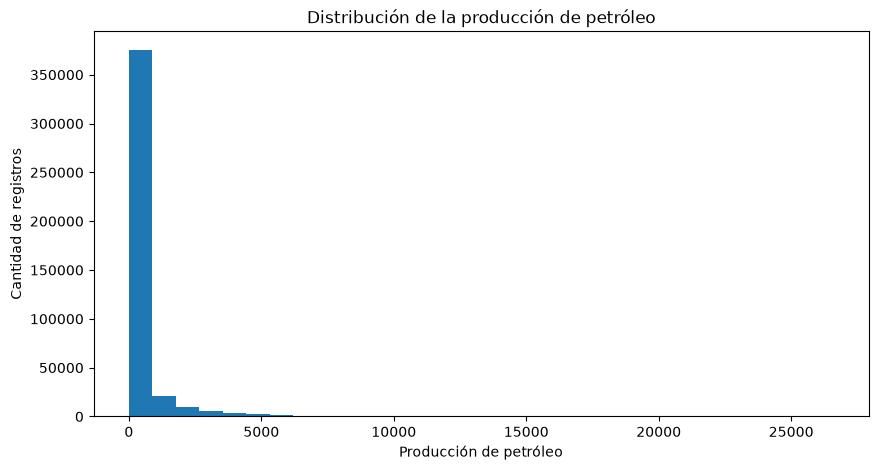

In [59]:
produccion["prod_pet"].plot(
    kind="hist",
    bins=30,
    figsize=(10, 5),
    title="Distribución de la producción de petróleo"
)

plt.xlabel("Producción de petróleo")
plt.ylabel("Cantidad de registros")
plt.show()

Los percentiles muestran que la producción de petróleo se encuentra fuertemente concentrada en valores bajos. La mediana es de 7,78, mientras que el 75% de los registros presenta una producción de hasta 122,29.

A medida que avanzamos hacia los percentiles superiores, los valores aumentan considerablemente: el 90% de los registros se encuentra por debajo de 991,74 y el 99% por debajo de 4.891,14. Sin embargo, el valor máximo alcanza 26.593,26.

Estos resultados indican que la variable `prod_pet` presenta una distribución sesgada hacia la derecha, con una concentración de registros en valores bajos y una cola formada por valores de producción considerablemente mayores.

El histograma completo permite observar la cola de la distribución, pero los valores más altos dificultan visualizar con detalle la zona donde se concentra la mayoría de los registros.

Para complementar el análisis, realizamos una segunda visualización considerando los registros hasta el percentil 99 de `prod_pet`. De esta manera podemos observar con mayor detalle el comportamiento de la gran mayoría de los registros sin eliminar estos valores del dataset original.

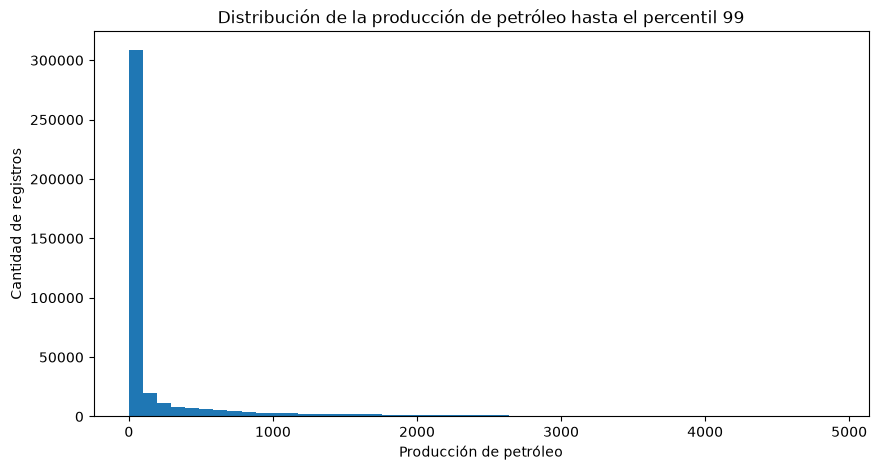

In [61]:
limite_p99 = produccion["prod_pet"].quantile(0.99)

produccion[produccion["prod_pet"] <= limite_p99]["prod_pet"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución de la producción de petróleo hasta el percentil 99"
)

plt.xlabel("Producción de petróleo")
plt.ylabel("Cantidad de registros")
plt.show()

La segunda visualización permite observar con mayor detalle la distribución de los valores que se encuentran dentro del 99% de los registros.

Se mantiene una concentración importante de observaciones en los valores bajos de producción y una disminución progresiva de la cantidad de registros a medida que aumenta la producción. Incluso al excluir de la visualización el 1% de los valores más altos, la distribución continúa presentando una marcada asimetría hacia la derecha.

Esto coincide con lo observado mediante los percentiles: mientras que el 75% de los registros tiene una producción de hasta 122,29, el 99% alcanza hasta 4.891,14. Por lo tanto, los valores elevados representan una proporción reducida del conjunto, pero generan una cola extensa en la distribución.

#### 3.4. Relación entre producción y estado del pozo

Hasta el momento analizamos las variables de forma individual. En esta etapa comenzamos a estudiar la relación entre ellas, tomando como referencia la producción de petróleo.

Primero analizamos cómo se distribuye `prod_pet` según el estado informado para cada registro. Esto nos permite comparar los niveles de producción entre los distintos estados y entender mejor la presencia de registros con producción nula o baja.


In [62]:
resumen_produccion_estado = (
    produccion
    .groupby("tipoestado")["prod_pet"]
    .agg(
        cantidad_registros="count",
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .sort_values("cantidad_registros", ascending=False)
)

display(resumen_produccion_estado)

,cantidad_registros,promedio,mediana,minimo,maximo
tipoestado,,,,,
Extracción Efectiva,348150,399.987669,20.38,0.000,26593.261000
Parado Transitoriamente,26440,19.583350,0.00,0.000,7727.100000
En Estudio,23861,3.810864,0.00,-0.001,4245.405667
A Abandonar,3724,0.377167,0.00,0.000,1404.570000
Abandonado,3724,0.133939,0.00,0.000,380.320000
Otras Situación Inactivo,3252,27.497251,0.00,0.000,10261.700000
En Reserva de Gas,3074,3.453981,0.00,0.000,3153.820448
En Espera de Reparación,2685,0.203588,0.00,0.000,326.080000
Otras Situación Activo,2318,228.447469,0.00,0.000,12656.480000


Para complementar el resumen anterior, analizamos qué proporción de los registros de cada estado presenta producción de petróleo mayor que cero.

Esto permite diferenciar los estados en los que la producción es frecuente de aquellos en los que predominan registros con producción nula.


In [63]:
produccion_por_estado = (
    produccion
    .groupby("tipoestado")
    .agg(
        cantidad_registros=("prod_pet", "count"),
        registros_con_produccion=("prod_pet", lambda x: (x > 0).sum())
    )
)

produccion_por_estado["porcentaje_con_produccion"] = (
    produccion_por_estado["registros_con_produccion"]
    / produccion_por_estado["cantidad_registros"]
    * 100
)

produccion_por_estado = produccion_por_estado.sort_values(
    "cantidad_registros",
    ascending=False
)

display(produccion_por_estado)

,cantidad_registros,registros_con_produccion,porcentaje_con_produccion
tipoestado,,,
Extracción Efectiva,348150,269047,77.279046
Parado Transitoriamente,26440,2618,9.901664
En Estudio,23861,128,0.536440
A Abandonar,3724,1,0.026853
Abandonado,3724,3,0.080559
Otras Situación Inactivo,3252,43,1.322263
En Reserva de Gas,3074,8,0.260247
En Espera de Reparación,2685,4,0.148976
Otras Situación Activo,2318,812,35.030198


#### 3.5. Distribución de `prod_pet` en escala logarítmica

En la sección 3.3.2 observamos que `prod_pet` presenta una distribución con una cola extensa hacia la derecha. En el histograma completo, la gran cantidad de registros con valores bajos hace que los rangos con valores elevados prácticamente no se distingan.

Para observar la distribución completa sin excluir registros, repetimos el histograma utilizando una escala logarítmica en el eje vertical.

En una escala logarítmica, cada marca del eje representa una cantidad diez veces mayor que la anterior (1, 10, 100, 1.000, ...). De esta manera podemos visualizar en un mismo gráfico tanto los rangos que contienen cientos de miles de registros como aquellos que contienen solo unos pocos.

In [ ]:
produccion["prod_pet"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución de la producción de petróleo (escala logarítmica)"
)

plt.yscale("log")
plt.xlabel("Producción de petróleo")
plt.ylabel("Cantidad de registros (escala logarítmica)")
plt.show()

El histograma en escala logarítmica permite observar la distribución completa de `prod_pet`, incluyendo los rangos de valores elevados que en el histograma original no se distinguían.

Se observa que la cantidad de registros disminuye de manera progresiva a medida que aumenta la producción, hasta valores cercanos a 15.000. A partir de ese punto aparecen solo unos pocos registros aislados, que llegan hasta el valor máximo de 26.593,26.

Estos registros con producción muy elevada deberán analizarse posteriormente como posibles valores atípicos (outliers), para determinar si corresponden a producciones reales o a errores de carga.

#### 3.6. Conversión de `fechaingreso` a tipo fecha

En la sección 2.4 observamos que la variable `fechaingreso` fue importada como texto (`str`). Como mencionamos en el análisis temporal, las fechas almacenadas como texto deben convertirse a tipo fecha para poder realizar cálculos y análisis cronológicos.

Antes de realizar la conversión, revisamos algunos valores para conocer el formato en el que se encuentran almacenadas las fechas.

In [ ]:
print("Primeros valores de 'fechaingreso':")
display(produccion["fechaingreso"].head())

Los valores incluyen la fecha, la hora y las fracciones de segundo, con el formato `año-mes-día hora:minutos:segundos.microsegundos`.

Para convertirlos utilizamos `pd.to_datetime()`, indicando el formato mediante las siguientes directivas:

- `%Y`: año;
- `%m`: mes;
- `%d`: día;
- `%H:%M:%S`: hora, minutos y segundos;
- `%f`: microsegundos.

Además, utilizamos `errors="coerce"` para que los valores que no respeten el formato se conviertan en `NaT` (Not a Time) en lugar de interrumpir la ejecución.

La conversión se guarda primero en una variable separada. De esta manera podemos verificar cuántos valores no pudieron convertirse antes de reemplazar la columna original.

In [ ]:
fechaingreso_convertida = pd.to_datetime(
    produccion["fechaingreso"],
    format="%Y-%m-%d %H:%M:%S.%f",
    errors="coerce"
)

print("Valores que no pudieron convertirse:", fechaingreso_convertida.isna().sum())

No se generaron valores `NaT`, por lo que todas las fechas fueron convertidas correctamente.

Por lo tanto, reemplazamos la columna original por la versión convertida y verificamos su nuevo tipo de dato.

In [ ]:
produccion["fechaingreso"] = fechaingreso_convertida

print("Tipo de dato de 'fechaingreso':", produccion["fechaingreso"].dtype)

Una vez convertida la variable, revisamos el rango de fechas disponible.

In [ ]:
print("Fecha de ingreso mínima:", produccion["fechaingreso"].min())
print("Fecha de ingreso máxima:", produccion["fechaingreso"].max())

La variable `fechaingreso` fue convertida correctamente a tipo fecha, sin generar valores faltantes.

Las fechas de ingreso van desde el 13/11/2006 hasta el 21/08/2026. La fecha máxima es posterior al último período informado en el dataset (julio de 2026), lo que indica que `fechaingreso` no representa el período al que corresponde la producción, sino la fecha en que el registro fue cargado.

Por este motivo, para los análisis temporales de la producción continuaremos utilizando las variables `anio` y `mes`.

### 4. Formateo de los datos

Hasta ahora nos concentramos en conocer los datasets tal como vienen. En esta sección vamos a revisar si cada columna tiene el tipo de dato que le corresponde y, cuando no sea así, la vamos a convertir.

Por ejemplo, en la sección 2.4 vimos que varias fechas fueron importadas como texto y que algunas columnas que solo indican "sí" o "no" también quedaron guardadas como texto. Mientras sigan así, no podemos ordenarlas, filtrarlas por período ni hacer cálculos con ellas.

Para no modificar los datos originales, trabajamos sobre una copia de cada dataset. Si algo sale mal, siempre podemos volver a los datos tal como fueron cargados.

In [ ]:
produccion_limpio = produccion.copy()
pozos_limpio = pozos.copy()
fracturacion_limpio = fracturacion.copy()

#### 4.1. Columnas con un único valor

Antes de formatear, conviene identificar si hay columnas que tienen el mismo valor en todos los registros. Una columna así no aporta información para diferenciar un pozo de otro ni un mes de otro.

Para encontrarlas contamos cuántos valores distintos tiene cada columna con `nunique()` y nos quedamos con las que tienen uno solo.

In [ ]:
print("Columnas con un único valor - Producción:")
display(produccion_limpio.nunique()[produccion_limpio.nunique() == 1])

print("Columnas con un único valor - Pozos:")
display(pozos_limpio.nunique()[pozos_limpio.nunique() == 1])

print("Columnas con un único valor - Fracturación:")
display(fracturacion_limpio.nunique()[fracturacion_limpio.nunique() == 1])

En el dataset de producción encontramos cuatro columnas con un único valor:

- `iny_co2` e `iny_otro`: todos los registros tienen 0, es decir, en ningún pozo se informó inyección de CO2 ni de otros fluidos;
- `habilitado`: todos los registros están habilitados;
- `tipo_de_recurso`: todos los registros son "NO CONVENCIONAL", lo cual tiene sentido porque el dataset es justamente de pozos no convencionales.

En pozos y fracturación no hay columnas en esta situación.

Por ahora no vamos a eliminar estas columnas. Las dejamos identificadas para descartarlas más adelante, cuando seleccionemos las variables para los modelos.

#### 4.2. Conversión de fechas

Los tres datasets tienen fechas guardadas como texto. Vamos a convertirlas a tipo fecha con `pd.to_datetime()`, de la misma forma que hicimos con `fechaingreso` en la sección 3.6.

En todos los casos usamos `errors="coerce"`, así los valores que no respeten el formato quedan como `NaT` en lugar de frenar la ejecución, y después contamos cuántos quedaron sin convertir.

##### 4.2.1. Fechas del dataset de producción

Además de `fechaingreso`, que ya convertimos, el dataset de producción tiene la columna `fecha_data`. Veamos cómo se ven sus valores.

In [ ]:
print("Primeros valores de 'fecha_data' en producción:")
display(produccion_limpio["fecha_data"].head())

Las fechas tienen el formato `año-mes-día`, sin hora. Además, todas parecen corresponder al último día de un mes. Las convertimos indicando ese formato.

In [ ]:
produccion_limpio["fecha_data"] = pd.to_datetime(
    produccion_limpio["fecha_data"],
    format="%Y-%m-%d",
    errors="coerce"
)

print("Valores que no pudieron convertirse:", produccion_limpio["fecha_data"].isna().sum())

Todos los valores se convirtieron correctamente.

Como `fecha_data` parece ser el último día del mes informado, comprobamos si su año y su mes coinciden con las columnas `anio` y `mes` de cada registro. Para obtener el año y el mes de una fecha usamos `.dt.year` y `.dt.month`.

In [ ]:
coincide_anio = produccion_limpio["fecha_data"].dt.year == produccion_limpio["anio"]
coincide_mes = produccion_limpio["fecha_data"].dt.month == produccion_limpio["mes"]

print("Registros donde 'fecha_data' coincide con 'anio' y 'mes':", (coincide_anio & coincide_mes).sum())
print("Total de registros:", len(produccion_limpio))

El año y el mes de `fecha_data` coinciden con `anio` y `mes` en todos los registros.

Esto confirma que `fecha_data` representa el período al que corresponde la producción, pero ya en formato de fecha. A diferencia de `fechaingreso`, que indica cuándo se cargó el registro, esta columna sí nos sirve para ordenar la producción de cada pozo en el tiempo.

##### 4.2.2. Fechas del dataset de pozos

El dataset de pozos tiene cuatro fechas: inicio y fin de la perforación, e inicio y fin de la terminación. Todas tienen el formato `año-mes-día`.

Como son varias columnas con el mismo formato, las recorremos con un `for` y aplicamos la misma conversión a cada una.

En este caso, las columnas ya tenían valores faltantes antes de convertirlas (lo vimos en la sección 2.6.2). Por eso comparamos la cantidad de nulos antes y después: si la cantidad aumenta, significa que algunos valores no pudieron convertirse.

In [ ]:
fechas_pozos = [
    "adjiv_fecha_inicio_perf",
    "adjiv_fecha_fin_perf",
    "adjiv_fecha_inicio_term",
    "adjiv_fecha_fin_term"
]

for columna in fechas_pozos:
    nulos_antes = pozos_limpio[columna].isna().sum()

    pozos_limpio[columna] = pd.to_datetime(
        pozos_limpio[columna],
        format="%Y-%m-%d",
        errors="coerce"
    )

    nulos_despues = pozos_limpio[columna].isna().sum()

    print(f"{columna}: {nulos_despues - nulos_antes} valores no pudieron convertirse")

La cantidad de nulos no aumentó en ninguna de las cuatro columnas, así que todas las fechas informadas se convirtieron correctamente. Los valores faltantes que ya existían siguen igual, ahora como `NaT`.

##### 4.2.3. Fechas del dataset de fracturación

En fracturación tenemos la fecha de inicio y de fin de cada fractura, que tienen el formato `año-mes-día`, y la columna `fecha_data`, que en este dataset incluye hora y microsegundos (igual que `fechaingreso` en producción).

In [ ]:
fracturacion_limpio["fecha_inicio_fractura"] = pd.to_datetime(
    fracturacion_limpio["fecha_inicio_fractura"],
    format="%Y-%m-%d",
    errors="coerce"
)

fracturacion_limpio["fecha_fin_fractura"] = pd.to_datetime(
    fracturacion_limpio["fecha_fin_fractura"],
    format="%Y-%m-%d",
    errors="coerce"
)

fracturacion_limpio["fecha_data"] = pd.to_datetime(
    fracturacion_limpio["fecha_data"],
    format="%Y-%m-%d %H:%M:%S.%f",
    errors="coerce"
)

print("Valores que no pudieron convertirse:")
print("fecha_inicio_fractura:", fracturacion_limpio["fecha_inicio_fractura"].isna().sum())
print("fecha_fin_fractura:", fracturacion_limpio["fecha_fin_fractura"].isna().sum())
print("fecha_data:", fracturacion_limpio["fecha_data"].isna().sum())

Las tres fechas se convirtieron sin problemas.

Revisando las columnas de este dataset también notamos que hay dos pares de columnas que parecen repetidas: `anio` y `anio_if` (año de inicio de la fractura), y `mes` y `mes_if` (mes de inicio de la fractura). Comprobamos si realmente tienen los mismos valores.

In [ ]:
print("Registros donde 'anio' coincide con 'anio_if':", (fracturacion_limpio["anio"] == fracturacion_limpio["anio_if"]).sum())
print("Registros donde 'mes' coincide con 'mes_if':", (fracturacion_limpio["mes"] == fracturacion_limpio["mes_if"]).sum())
print("Total de registros:", len(fracturacion_limpio))

Las columnas coinciden en todos los registros, así que `anio` y `mes` repiten la misma información que `anio_if` y `mes_if`. Igual que con las columnas de un único valor, las dejamos identificadas para no usar las dos versiones más adelante.

#### 4.3. Columnas de tipo sí/no

Algunas columnas solo indican si algo se cumple o no, pero están guardadas como texto:

- `rectificado` y `habilitado`, en producción, usan `t` (verdadero) y `f` (falso);
- `gasplus`, en pozos, usa `si` y `no`.

Primero revisamos qué valores tienen.

In [ ]:
print("Valores de 'rectificado':")
display(produccion_limpio["rectificado"].value_counts())

print("Valores de 'habilitado':")
display(produccion_limpio["habilitado"].value_counts())

print("Valores de 'gasplus':")
display(pozos_limpio["gasplus"].value_counts())

Las tres columnas solo tienen los dos valores esperados y no tienen nulos, así que podemos convertirlas a tipo booleano (`True` / `False`) sin perder información.

Para eso reemplazamos cada texto por su valor booleano usando `replace()` con un diccionario, y después indicamos el tipo con `astype(bool)`.

In [ ]:
produccion_limpio["rectificado"] = produccion_limpio["rectificado"].replace({"t": True, "f": False}).astype(bool)
produccion_limpio["habilitado"] = produccion_limpio["habilitado"].replace({"t": True, "f": False}).astype(bool)
pozos_limpio["gasplus"] = pozos_limpio["gasplus"].replace({"si": True, "no": False}).astype(bool)

print("Valores de 'rectificado':")
display(produccion_limpio["rectificado"].value_counts())

print("Valores de 'gasplus':")
display(pozos_limpio["gasplus"].value_counts())

La conversión mantuvo las mismas cantidades que antes: 694 registros de producción fueron rectificados y 1.114 pozos pertenecen al programa Gas Plus.

#### 4.4. Estandarización de las formaciones

Las formaciones aparecen en los tres datasets, y más adelante nos va a interesar compararlas entre sí. Para eso es importante que el mismo nombre esté escrito siempre de la misma forma. Veamos cómo están escritas en producción.

In [ ]:
print("Formaciones en producción:")
print(produccion_limpio["formacion"].unique())

Casi todas las formaciones están en minúsculas, excepto `ANITA`, que está en mayúsculas. En el dataset de pozos, además, encontramos nombres que empiezan con mayúscula (como `Piedra Clavada`) y dos formaciones con un espacio de más al final (`glauconitico ` y `lonco trapial `).

Para que todas queden escritas igual, las pasamos a mayúsculas con `.str.upper()`, que es el mismo formato que ya usan otras columnas como `cuenca`. Los dos casos con espacio al final los corregimos con `replace()`.

In [ ]:
produccion_limpio["formacion"] = produccion_limpio["formacion"].str.upper()
pozos_limpio["formacion"] = pozos_limpio["formacion"].str.upper()
fracturacion_limpio["formacion_productiva"] = fracturacion_limpio["formacion_productiva"].str.upper()

pozos_limpio["formacion"] = pozos_limpio["formacion"].replace({
    "GLAUCONITICO ": "GLAUCONITICO",
    "LONCO TRAPIAL ": "LONCO TRAPIAL"
})

print("Formaciones en producción:")
print(produccion_limpio["formacion"].unique())

Ahora todas las formaciones están escritas en mayúsculas y con el mismo formato en los tres datasets.

#### 4.5. Resumen del formateo

Para terminar, verificamos que las columnas que modificamos tengan el tipo de dato correcto.

In [ ]:
print("Tipos de datos de las columnas formateadas - Producción:")
display(produccion_limpio[["fechaingreso", "fecha_data", "rectificado", "habilitado"]].dtypes)

print("Tipos de datos de las columnas formateadas - Pozos:")
display(pozos_limpio[fechas_pozos + ["gasplus"]].dtypes)

print("Tipos de datos de las columnas formateadas - Fracturación:")
display(fracturacion_limpio[["fecha_inicio_fractura", "fecha_fin_fractura", "fecha_data"]].dtypes)

Todas las fechas quedaron con tipo `datetime64` y las columnas de sí/no con tipo `bool`.

En resumen, en esta sección:

- identificamos cuatro columnas de producción con un único valor y dos columnas repetidas en fracturación;
- convertimos a tipo fecha todas las fechas que estaban guardadas como texto;
- comprobamos que `fecha_data` representa el período de producción de cada registro;
- convertimos a booleano las columnas de tipo sí/no;
- unificamos la forma en que están escritas las formaciones.

En ningún caso eliminamos registros ni columnas.

### 5. Valores mínimos y máximos

Con los datos ya formateados, revisamos los valores mínimos y máximos de las principales variables de cada dataset.

La idea es comprobar si los valores tienen sentido. Por ejemplo, una producción no puede ser negativa y un mes no puede tener más de 31 días. Si encontramos valores que no son posibles, los identificamos para decidir más adelante qué hacer con ellos.

#### 5.1. Dataset de producción

In [ ]:
variables_rango_produccion = [
    "prod_pet",
    "prod_gas",
    "prod_agua",
    "tef",
    "profundidad",
    "coordenadax",
    "coordenaday"
]

display(produccion_limpio[variables_rango_produccion].agg(["min", "max"]).T)

A primera vista aparecen varios valores que llaman la atención:

- `prod_pet` y `prod_gas` tienen valores mínimos negativos;
- `tef` llega a 79,34, cuando representa los días efectivos de producción en un mes;
- `profundidad` tiene valores de 0 y un máximo de 378.939 metros;
- `coordenadax` tiene un máximo de -38,59 y `coordenaday` un mínimo de -69,42, que parecen estar invertidos.

Vamos a revisar cada caso por separado.

Empezamos por los registros con producción negativa.

In [ ]:
registros_negativos = produccion_limpio[
    (produccion_limpio["prod_pet"] < 0) | (produccion_limpio["prod_gas"] < 0)
]

display(registros_negativos[["idpozo", "anio", "mes", "prod_pet", "prod_gas", "tipoestado"]])

Son solo tres registros: dos pozos con producción de gas negativa en mayo de 2020 y el registro con producción de petróleo de -0,001 que ya habíamos encontrado en la sección 3.3.1.

Una producción negativa no es posible, por lo que probablemente se trate de ajustes o errores de carga. Al ser tan pocos, no afectan al análisis general, pero habrá que tratarlos antes de entrenar los modelos.

Seguimos con `tef`, que indica cuántos días produjo el pozo durante el mes. Como un mes tiene como máximo 31 días, contamos cuántos registros superan ese valor. También contamos cuántos tienen 0 días.

In [ ]:
print("Registros con 'tef' mayor a 31 días:", (produccion_limpio["tef"] > 31).sum())
print("Registros con 'tef' igual a 0:", (produccion_limpio["tef"] == 0).sum())

Hay 15 registros con más de 31 días efectivos, lo cual no es posible y seguramente corresponde a errores de carga.

Los registros con 0 días son muchos más (81.867), pero en este caso el valor sí tiene sentido: representa meses en los que el pozo no estuvo produciendo.

Ahora revisamos la profundidad. Contamos los registros con profundidad 0 y los que superan los 10.000 metros, que está muy por encima de la profundidad de cualquier pozo de estas cuencas.

Como en producción cada pozo aparece en muchos registros, también contamos a cuántos pozos distintos corresponden.

In [ ]:
print("Registros con profundidad igual a 0:", (produccion_limpio["profundidad"] == 0).sum())
print("Registros con profundidad mayor a 10.000 metros:", (produccion_limpio["profundidad"] > 10000).sum())

pozos_profundidad_cero = produccion_limpio[produccion_limpio["profundidad"] == 0]["idpozo"].nunique()
pozos_profundidad_alta = produccion_limpio[produccion_limpio["profundidad"] > 10000]["idpozo"].nunique()

print("Pozos con profundidad igual a 0:", pozos_profundidad_cero)
print("Pozos con profundidad mayor a 10.000 metros:", pozos_profundidad_alta)

Los 5.738 registros con profundidad 0 corresponden a 164 pozos. Una profundidad de 0 no tiene sentido para un pozo en producción, por lo que probablemente se trate de un dato no informado.

Los 122 registros con más de 10.000 metros corresponden a un solo pozo, que tiene cargada una profundidad de 378.939 metros. Este valor es claramente un error.

Por último, revisamos las coordenadas. En Argentina, la longitud (`coordenadax`) va aproximadamente de -73 a -53 y la latitud (`coordenaday`) de -55 a -22. Buscamos registros donde la longitud sea mayor a -50 y la latitud menor a -60, que son valores fuera del país.

In [ ]:
coordenadas_invertidas = produccion_limpio[
    (produccion_limpio["coordenadax"] > -50) & (produccion_limpio["coordenaday"] < -60)
]

print("Registros con coordenadas posiblemente invertidas:", len(coordenadas_invertidas))
print("Pozos con coordenadas posiblemente invertidas:", coordenadas_invertidas["idpozo"].nunique())

display(coordenadas_invertidas[["idpozo", "sigla", "coordenadax", "coordenaday"]].head())

Los 68 registros corresponden a un único pozo que tiene las coordenadas cargadas al revés: la longitud está en la columna de latitud y viceversa. Si las intercambiáramos, el pozo quedaría ubicado en la provincia de Neuquén, que es donde corresponde.

#### 5.2. Dataset de pozos

In [ ]:
display(pozos_limpio[["cota", "profundidad"] + fechas_pozos].agg(["min", "max"]).T)

En pozos vuelve a aparecer la profundidad máxima de 378.939 metros y también profundidades de 0. Además, la cota (altura del terreno) tiene un mínimo de -100 metros.

Lo más llamativo son las fechas: las cuatro tienen como mínimo el 1 de enero de 1900. Es muy poco probable que se hayan perforado pozos no convencionales en esa fecha, así que contamos cuántos pozos tienen ese año.

In [ ]:
for columna in fechas_pozos:
    print(f"{columna}: {(pozos_limpio[columna].dt.year == 1900).sum()} registros con año 1900")

Entre 33 y 38 pozos tienen fechas del año 1900, según la columna. Todo indica que el 01/01/1900 se usó para completar fechas desconocidas, por lo que en la práctica estos valores deberían considerarse faltantes.

También revisamos que las fechas tengan un orden lógico: el fin de la perforación no debería ser anterior a su inicio, y lo mismo para la terminación.

In [ ]:
perforacion_invertida = pozos_limpio["adjiv_fecha_fin_perf"] < pozos_limpio["adjiv_fecha_inicio_perf"]
terminacion_invertida = pozos_limpio["adjiv_fecha_fin_term"] < pozos_limpio["adjiv_fecha_inicio_term"]

print("Pozos con fin de perforación anterior al inicio:", perforacion_invertida.sum())
print("Pozos con fin de terminación anterior al inicio:", terminacion_invertida.sum())

Solo 3 pozos tienen la fecha de fin de perforación anterior a la de inicio. En la terminación no hay casos así.

#### 5.3. Dataset de fracturación

In [ ]:
variables_rango_fracturacion = [
    "longitud_rama_horizontal_m",
    "cantidad_fracturas",
    "arena_bombeada_nacional_tn",
    "arena_bombeada_importada_tn",
    "agua_inyectada_m3",
    "presion_maxima_psi",
    "potencia_equipos_fractura_hp",
    "fecha_inicio_fractura",
    "fecha_fin_fractura"
]

display(fracturacion_limpio[variables_rango_fracturacion].agg(["min", "max"]).T)

En fracturación también aparecen algunos valores para revisar:

- la fecha de inicio de fractura más reciente es el 05/12/2026, una fecha que todavía no ocurrió;
- la presión máxima llega a más de 209.000 psi y la potencia de los equipos a más de 232.000 hp, valores muy por encima del resto;
- hay registros con longitud de rama horizontal, agua inyectada y presión igual a 0.

Revisamos primero las fechas. Tomamos como referencia la fecha de la última carga de datos (`fecha_data`), ya que ninguna fractura debería comenzar después de haber sido informada.

In [ ]:
fecha_ultima_carga = fracturacion_limpio["fecha_data"].max()

print("Fecha de la última carga de datos:", fecha_ultima_carga)
print("Fracturas con fecha de inicio posterior a la última carga:", (fracturacion_limpio["fecha_inicio_fractura"] > fecha_ultima_carga).sum())
print("Fracturas con fecha de fin anterior a la de inicio:", (fracturacion_limpio["fecha_fin_fractura"] < fracturacion_limpio["fecha_inicio_fractura"]).sum())

Hay 3 fracturas con fecha de inicio posterior a la última carga de datos y 41 fracturas que terminan antes de haber empezado. En ambos casos se trata de errores en las fechas.

Ahora revisamos los valores en 0 y las presiones más altas.

In [ ]:
print("Registros con longitud de rama horizontal igual a 0:", (fracturacion_limpio["longitud_rama_horizontal_m"] == 0).sum())
print("Registros con agua inyectada igual a 0:", (fracturacion_limpio["agua_inyectada_m3"] == 0).sum())
print("Registros con presión máxima igual a 0:", (fracturacion_limpio["presion_maxima_psi"] == 0).sum())
print("Registros con presión máxima mayor a 20.000 psi:", (fracturacion_limpio["presion_maxima_psi"] > 20000).sum())

Los 2.054 registros con longitud de rama horizontal igual a 0 no son un error: corresponden a pozos verticales, que no tienen rama horizontal. Representan el 42% de los registros de fracturación.

En cambio, que la presión máxima sea 0 en 78 registros no es posible durante una fractura, así que probablemente sean datos no informados. Las presiones superiores a 20.000 psi (12 registros) también son sospechosas, ya que el resto de los valores se concentra por debajo de ese número.

#### 5.4. Conclusiones sobre los valores mínimos y máximos

La revisión de los rangos nos permitió encontrar valores que no son posibles o que no tienen sentido:

- **Producción:** 3 registros con producción negativa, 15 registros con más de 31 días efectivos, 164 pozos con profundidad 0, un pozo con 378.939 metros de profundidad y un pozo con las coordenadas invertidas.
- **Pozos:** fechas del año 1900 que probablemente reemplazan a fechas desconocidas y 3 pozos con fechas de perforación en orden invertido.
- **Fracturación:** 3 fracturas con fecha futura, 41 con la fecha de fin anterior a la de inicio, presiones iguales a 0 y algunas presiones y potencias extremadamente altas.

En general, se trata de pocos registros en comparación con el tamaño de cada dataset. Por ahora los dejamos identificados y no los modificamos. Su tratamiento lo vamos a definir en la etapa de limpieza, junto con los valores faltantes.

También vimos que no todos los ceros son errores: un pozo puede tener 0 días de producción en un mes o no tener rama horizontal. Por eso, antes de tratar un cero como faltante, hay que entender qué significa en cada variable.

### 6. Histogramas

En la sección 3.3 analizamos la distribución de la producción de petróleo. Ahora hacemos lo mismo con otras variables que pueden ser importantes para entender el comportamiento de los pozos.

Para las variables con una cola muy larga, como la producción de gas y de agua, usamos la escala logarítmica en el eje vertical, igual que en la sección 3.5.

#### 6.1. Producción de gas

In [ ]:
produccion_limpio["prod_gas"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución de la producción de gas (escala logarítmica)"
)

plt.yscale("log")
plt.xlabel("Producción de gas")
plt.ylabel("Cantidad de registros (escala logarítmica)")
plt.show()

La producción de gas tiene una forma muy parecida a la del petróleo: la mayoría de los registros se concentra en valores bajos y la cantidad disminuye de forma pareja a medida que la producción aumenta. Por encima de 30.000 solo quedan unos pocos registros aislados.

#### 6.2. Producción de agua

In [ ]:
produccion_limpio["prod_agua"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución de la producción de agua (escala logarítmica)"
)

plt.yscale("log")
plt.xlabel("Producción de agua")
plt.ylabel("Cantidad de registros (escala logarítmica)")
plt.show()

Con la producción de agua pasa lo mismo: muchos registros con valores bajos y una cola larga hacia la derecha. En este caso la cantidad de registros baja más rápido, y por encima de 15.000 los registros ya son muy pocos.

#### 6.3. Días efectivos de producción (`tef`)

In [ ]:
produccion_limpio["tef"].plot(
    kind="hist",
    bins=40,
    figsize=(10, 5),
    title="Distribución de los días efectivos de producción (tef)"
)

plt.xlabel("Días efectivos de producción en el mes")
plt.ylabel("Cantidad de registros")
plt.show()

Este histograma muestra dos grupos muy marcados:

- una gran cantidad de registros con 0 días, que son los meses en que el pozo no produjo;
- la mayor concentración entre 28 y 31 días, que son los meses en que el pozo produjo prácticamente todo el mes.

Entre esos dos extremos hay menos registros, que corresponden a meses en los que el pozo estuvo parado algunos días. A la derecha casi no se ven los 15 registros con más de 31 días que encontramos en la sección 5.1.

Esta variable puede ser útil más adelante, ya que la producción de un mes depende en gran parte de cuántos días estuvo activo el pozo.

#### 6.4. Profundidad de los pozos

Para analizar la profundidad usamos el dataset de pozos, donde cada pozo aparece una sola vez. Si usáramos el de producción, los pozos con muchos meses de historia pesarían más en el gráfico.

Filtramos los pozos no convencionales y dejamos afuera las profundidades de 0 y mayores a 10.000 metros que identificamos en la sección 5.

In [ ]:
pozos_no_convencionales = pozos_limpio[pozos_limpio["tipo_recurso"] == "NO CONVENCIONAL"]

pozos_no_convencionales[
    (pozos_no_convencionales["profundidad"] > 0) & (pozos_no_convencionales["profundidad"] <= 10000)
]["profundidad"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución de la profundidad de los pozos no convencionales"
)

plt.xlabel("Profundidad (metros)")
plt.ylabel("Cantidad de pozos")
plt.show()

La profundidad no se concentra alrededor de un único valor, sino que muestra varios grupos: uno cerca de los 1.500 a 2.000 metros, otro muy marcado cerca de los 3.000 metros y un grupo amplio entre los 5.000 y 6.500 metros.

Estos grupos podrían corresponder a distintas formaciones o tipos de pozo, algo que puede ser interesante revisar más adelante en la etapa de clustering.

#### 6.5. Longitud de la rama horizontal

In [ ]:
fracturacion_limpio["longitud_rama_horizontal_m"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución de la longitud de la rama horizontal"
)

plt.xlabel("Longitud de la rama horizontal (metros)")
plt.ylabel("Cantidad de registros")
plt.show()

El histograma muestra claramente dos tipos de pozos. Por un lado, una barra muy alta en 0, que corresponde a los pozos verticales. Por otro, los pozos horizontales, con ramas que en su mayoría van de 1.000 a 4.000 metros y se concentran cerca de los 2.500 metros.

#### 6.6. Cantidad de fracturas

In [ ]:
fracturacion_limpio["cantidad_fracturas"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución de la cantidad de fracturas"
)

plt.xlabel("Cantidad de fracturas")
plt.ylabel("Cantidad de registros")
plt.show()

La cantidad de fracturas también muestra la diferencia entre pozos verticales y horizontales. Un grupo grande de registros (cerca del 38%) tiene muy pocas fracturas, entre 1 y 5, lo que coincide con los pozos verticales. El resto se distribuye de forma bastante pareja entre 20 y 60 fracturas, con algunos casos que superan las 80.

#### 6.7. Agua inyectada en la fracturación

In [ ]:
fracturacion_limpio["agua_inyectada_m3"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución del agua inyectada en la fracturación"
)

plt.xlabel("Agua inyectada (m3)")
plt.ylabel("Cantidad de registros")
plt.show()

El agua inyectada repite el mismo patrón: un grupo grande con valores cercanos a 0 y otro grupo que se concentra entre 30.000 y 100.000 m3. Muy pocos registros superan los 150.000 m3, y el máximo (más de 537.000 m3) queda muy alejado del resto.

#### 6.8. Conclusiones de los histogramas

- La producción de gas y de agua tiene la misma forma que la de petróleo: muchos registros con valores bajos y una cola larga de valores altos.
- La variable `tef` muestra que, en la mayoría de los meses, los pozos producen todo el mes o directamente no producen.
- La profundidad de los pozos no convencionales se agrupa en varios rangos distintos.
- En fracturación se distinguen claramente dos tipos de pozos: los verticales, sin rama horizontal y con pocas fracturas, y los horizontales, con ramas largas, muchas fracturas y más agua inyectada.

### 7. Comparaciones

Hasta ahora analizamos cada variable por separado. En esta sección comparamos algunas variables entre sí para entender mejor de qué depende la producción de petróleo.

#### 7.1. Producción de petróleo según el tipo de pozo

En la sección 3.3.1 vimos que el 35% de los registros no tiene producción de petróleo. Una posible explicación es que el dataset incluye pozos de gas, que no necesariamente producen petróleo.

Para comprobarlo, agrupamos los registros por `tipopozo` y calculamos la mediana de producción y el porcentaje de registros con producción de petróleo.

In [ ]:
produccion_por_tipo_pozo = (
    produccion_limpio
    .groupby("tipopozo")
    .agg(
        cantidad_registros=("prod_pet", "count"),
        mediana_prod_pet=("prod_pet", "median"),
        registros_con_produccion=("prod_pet", lambda x: (x > 0).sum())
    )
)

produccion_por_tipo_pozo["porcentaje_con_produccion"] = (
    produccion_por_tipo_pozo["registros_con_produccion"]
    / produccion_por_tipo_pozo["cantidad_registros"]
    * 100
)

produccion_por_tipo_pozo = produccion_por_tipo_pozo.sort_values(
    "cantidad_registros",
    ascending=False
)

display(produccion_por_tipo_pozo)

In [ ]:
produccion_por_tipo_pozo["porcentaje_con_produccion"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Porcentaje de registros con producción de petróleo según tipo de pozo"
)

plt.xlabel("Tipo de pozo")
plt.ylabel("Registros con producción de petróleo (%)")
plt.xticks(rotation=45)
plt.show()

Los resultados confirman la sospecha. Más de la mitad de los registros del dataset corresponden a pozos gasíferos (228.004), y en ellos la mediana de producción de petróleo es de apenas 1,08. En cambio, los pozos petrolíferos tienen una mediana de 148,20 y el 86% de sus registros tiene producción de petróleo.

Los pozos de tipo "Otro tipo", sumideros y de inyección casi no producen petróleo. El caso de "Acuífero" aparece con el 100%, pero corresponde a un único registro, así que no es representativo.

Esto es importante para el objetivo del proyecto: si queremos predecir la producción de petróleo, vamos a tener que decidir si incluimos todos los tipos de pozo o si nos concentramos en los petrolíferos.

#### 7.2. Evolución de la producción a lo largo de los años

Ahora analizamos cómo cambió la producción total de petróleo a lo largo del tiempo, sumando la producción de todos los pozos para cada año.

In [ ]:
produccion_anual = produccion_limpio.groupby("anio")["prod_pet"].sum()

produccion_anual.plot(
    kind="bar",
    figsize=(12, 5),
    title="Producción total de petróleo por año"
)

plt.xlabel("Año")
plt.ylabel("Producción total de petróleo")
plt.show()

La producción total de petróleo creció de forma sostenida, sobre todo a partir de 2014. En 2025 fue unas 19 veces mayor que en 2015.

Hay que tener en cuenta que 2026 solo tiene datos de enero a julio. Por eso su barra es más baja que la de 2025, aunque con 7 meses ya supera la producción de todo 2023.

Para saber si este crecimiento se debe a que hay más pozos produciendo, contamos cuántos pozos distintos tuvieron producción de petróleo cada año.

In [ ]:
pozos_con_produccion_por_anio = (
    produccion_limpio[produccion_limpio["prod_pet"] > 0]
    .groupby("anio")["idpozo"]
    .nunique()
)

pozos_con_produccion_por_anio.plot(
    kind="bar",
    figsize=(12, 5),
    title="Cantidad de pozos con producción de petróleo por año"
)

plt.xlabel("Año")
plt.ylabel("Cantidad de pozos")
plt.show()

La cantidad de pozos con producción de petróleo también creció año a año: pasó de 52 pozos en 2006 a 960 en 2015 y a 3.564 en 2025. En 2026, con solo 7 meses, ya hay 3.893 pozos con producción.

Comparando los dos gráficos, vemos que la producción total creció más rápido que la cantidad de pozos. Esto indica que, además de haber más pozos, en promedio cada pozo produce más que antes.

#### 7.3. Producción de petróleo por formación

En la sección 3.2 vimos que Vaca Muerta es la formación con más registros. Ahora calculamos qué porcentaje de la producción total de petróleo aporta cada formación.

In [ ]:
produccion_por_formacion = (
    produccion_limpio
    .groupby("formacion")["prod_pet"]
    .sum()
    .sort_values(ascending=False)
)

porcentaje_por_formacion = produccion_por_formacion / produccion_por_formacion.sum() * 100

display(porcentaje_por_formacion.head(5))

Vaca Muerta concentra el 96,4% de toda la producción de petróleo del dataset, a pesar de tener solo alrededor de la mitad de los registros. La segunda formación, Lajas, aporta menos del 2%.

Esto muestra que el comportamiento del dataset está dominado casi por completo por los pozos de Vaca Muerta.

#### 7.4. Evolución de la fracturación

En la sección 6.5 vimos que los pozos horizontales tienen ramas mucho más largas y más fracturas que los verticales. Ahora analizamos cómo cambiaron estas características con los años.

Para esto nos quedamos solo con los pozos horizontales (con longitud de rama mayor a 0) y calculamos, para cada año, la mediana de la longitud de la rama y de la cantidad de fracturas.

In [ ]:
fracturas_horizontales = fracturacion_limpio[fracturacion_limpio["longitud_rama_horizontal_m"] > 0]

evolucion_fracturas = fracturas_horizontales.groupby("anio").agg(
    cantidad_registros=("idpozo", "count"),
    mediana_rama_horizontal=("longitud_rama_horizontal_m", "median"),
    mediana_fracturas=("cantidad_fracturas", "median")
)

display(evolucion_fracturas)

In [ ]:
evolucion_fracturas["mediana_rama_horizontal"].plot(
    kind="bar",
    figsize=(12, 5),
    title="Mediana de la longitud de la rama horizontal por año"
)

plt.xlabel("Año de inicio de la fractura")
plt.ylabel("Longitud de la rama horizontal (metros)")
plt.show()

La longitud de la rama horizontal aumentó de forma constante: la mediana pasó de unos 1.000 metros en 2014 a unos 3.000 metros en 2025 y 2026. La cantidad de fracturas acompañó ese crecimiento, pasando de una mediana de 9,5 en 2014 a 50 en 2025.

Los valores de 2009 a 2013 son más irregulares porque hay muy pocos registros por año (entre 2 y 26), así que no son tan representativos.

Esto coincide con lo que vimos en la sección 7.2: los pozos más nuevos tienen ramas más largas y más fracturas, lo que podría explicar por qué producen más.

Para ver la relación entre la longitud de la rama y la cantidad de fracturas, usamos un gráfico de dispersión, donde cada punto es un registro de fracturación.

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(
    fracturas_horizontales["longitud_rama_horizontal_m"],
    fracturas_horizontales["cantidad_fracturas"],
    alpha=0.3
)

plt.title("Longitud de la rama horizontal y cantidad de fracturas")
plt.xlabel("Longitud de la rama horizontal (metros)")
plt.ylabel("Cantidad de fracturas")
plt.show()

El gráfico muestra una relación clara: cuanto más larga es la rama horizontal, más fracturas tiene el pozo. Los puntos forman una franja que sube de izquierda a derecha, con pocos casos alejados.

Tiene sentido, porque las fracturas se hacen a lo largo de la rama. Para los modelos esto significa que ambas variables aportan información parecida, algo que habrá que tener en cuenta al elegir las variables.

#### 7.5. Comparación de métodos para detectar outliers en `prod_pet`

En las secciones 3.5 y 6 vimos que la producción tiene una cola larga de valores altos. Para saber cuántos de esos valores se consideran atípicos, comparamos los dos métodos habituales: el rango intercuartílico (RIC) y el z-score.

Con el RIC, un valor es atípico si está por debajo de Q1 - 1,5 × RIC o por encima de Q3 + 1,5 × RIC.

In [ ]:
q1 = produccion_limpio["prod_pet"].quantile(0.25)
q3 = produccion_limpio["prod_pet"].quantile(0.75)
ric = q3 - q1

limite_inferior = q1 - 1.5 * ric
limite_superior = q3 + 1.5 * ric

outliers_ric = produccion_limpio[
    (produccion_limpio["prod_pet"] < limite_inferior) | (produccion_limpio["prod_pet"] > limite_superior)
]

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Outliers según RIC:", len(outliers_ric))
print(f"Porcentaje de outliers según RIC: {len(outliers_ric) / len(produccion_limpio) * 100:.2f}%")

Con el z-score, un valor es atípico si se aleja más de 3 desvíos estándar de la media.

In [ ]:
media_prod_pet = produccion_limpio["prod_pet"].mean()
desvio_prod_pet = produccion_limpio["prod_pet"].std()

z_score = (produccion_limpio["prod_pet"] - media_prod_pet) / desvio_prod_pet

outliers_z = produccion_limpio[(z_score > 3) | (z_score < -3)]

print("Valor de producción equivalente a z-score = 3:", media_prod_pet + 3 * desvio_prod_pet)
print("Outliers según z-score:", len(outliers_z))
print(f"Porcentaje de outliers según z-score: {len(outliers_z) / len(produccion_limpio) * 100:.2f}%")

Los dos métodos dan resultados muy distintos:

- el RIC marca como atípicos todos los registros con producción mayor a 305,73, lo que representa casi el 19% del dataset;
- el z-score solo marca los registros con producción mayor a 3.147,57, que son el 2,56%.

La diferencia se explica por la forma de la distribución. Como la mayoría de los registros tiene producción baja o igual a 0, el RIC queda muy chico y cualquier producción moderada ya aparece como atípica.

El diagrama de caja muestra claramente esta situación: la caja queda aplastada cerca de 0 y todos los valores altos aparecen como puntos sueltos por encima.

In [ ]:
plt.figure(figsize=(6, 6))

plt.boxplot(produccion_limpio["prod_pet"])

plt.title("Diagrama de caja de la producción de petróleo")
plt.ylabel("Producción de petróleo")
plt.show()

Para entender a qué pozos corresponden los valores atípicos, vemos su tipo de pozo y su formación.

In [ ]:
print("Outliers según z-score por tipo de pozo:")
display(outliers_z["tipopozo"].value_counts())

print("Outliers según z-score por formación:")
display(outliers_z["formacion"].value_counts())

Casi todos los valores atípicos según el z-score corresponden a pozos petrolíferos de Vaca Muerta, que son justamente los que más producen.

Por lo tanto, en este caso los valores atípicos no parecen errores, sino pozos con una producción real muy alta. Eliminarlos haría que perdamos los pozos más importantes del dataset. Por eso no los vamos a tratar como errores y los vamos a conservar para el análisis.

### 8. Conclusiones generales

A partir del formateo y la exploración de los datos llegamos a las siguientes conclusiones:

**Sobre la calidad de los datos**

- Convertimos todas las fechas a tipo fecha y las columnas de sí/no a booleanas, y unificamos la escritura de las formaciones.
- Identificamos columnas que no aportan información, ya sea porque tienen un único valor o porque repiten los datos de otra columna.
- Encontramos algunos valores imposibles (producciones negativas, más de 31 días en un mes, profundidades de 0 o de 378.939 metros, fechas de 1900 o futuras, coordenadas invertidas). Son pocos en relación con el total y los vamos a tratar en la etapa de limpieza.

**Sobre el comportamiento de la producción**

- La producción de petróleo, gas y agua se concentra en valores bajos y tiene una cola larga de valores altos.
- Gran parte de los registros sin producción de petróleo corresponden a pozos gasíferos o de otros tipos. Los pozos petrolíferos producen petróleo en el 86% de sus registros.
- Vaca Muerta concentra el 96,4% de la producción total de petróleo.
- La producción creció fuertemente a lo largo de los años, más rápido que la cantidad de pozos.

**Sobre la fracturación**

- Hay dos grupos claros de pozos: verticales, con pocas fracturas, y horizontales, con ramas largas y muchas fracturas.
- Con los años, las ramas horizontales se hicieron más largas y la cantidad de fracturas aumentó, lo que podría explicar el aumento de producción por pozo.

**Próximos pasos**

- Decidir cómo tratar los valores imposibles que identificamos.
- Definir si el modelo se va a entrenar con todos los tipos de pozo o solo con los petrolíferos.
- Relacionar los datasets mediante `idpozo` para estudiar cómo influyen las características de los pozos y de la fracturación en la producción.